# Lab 6
### Morphology

Skimage morphology operators' documentation:
https://scikit-image.org/docs/dev/api/skimage.morphology.html

In [6]:
from commonfunctions import *
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.morphology import (
    binary_erosion,
    binary_dilation,
    binary_closing,
    skeletonize,
    thin,
    rectangle,        # structuring element factory (use this one)
    binary_opening
)
from skimage.measure import find_contours
from skimage.filters import threshold_otsu
from matplotlib.patches import Rectangle  # for drawing boxes on plots

# Show the figures / plots inside the notebook
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


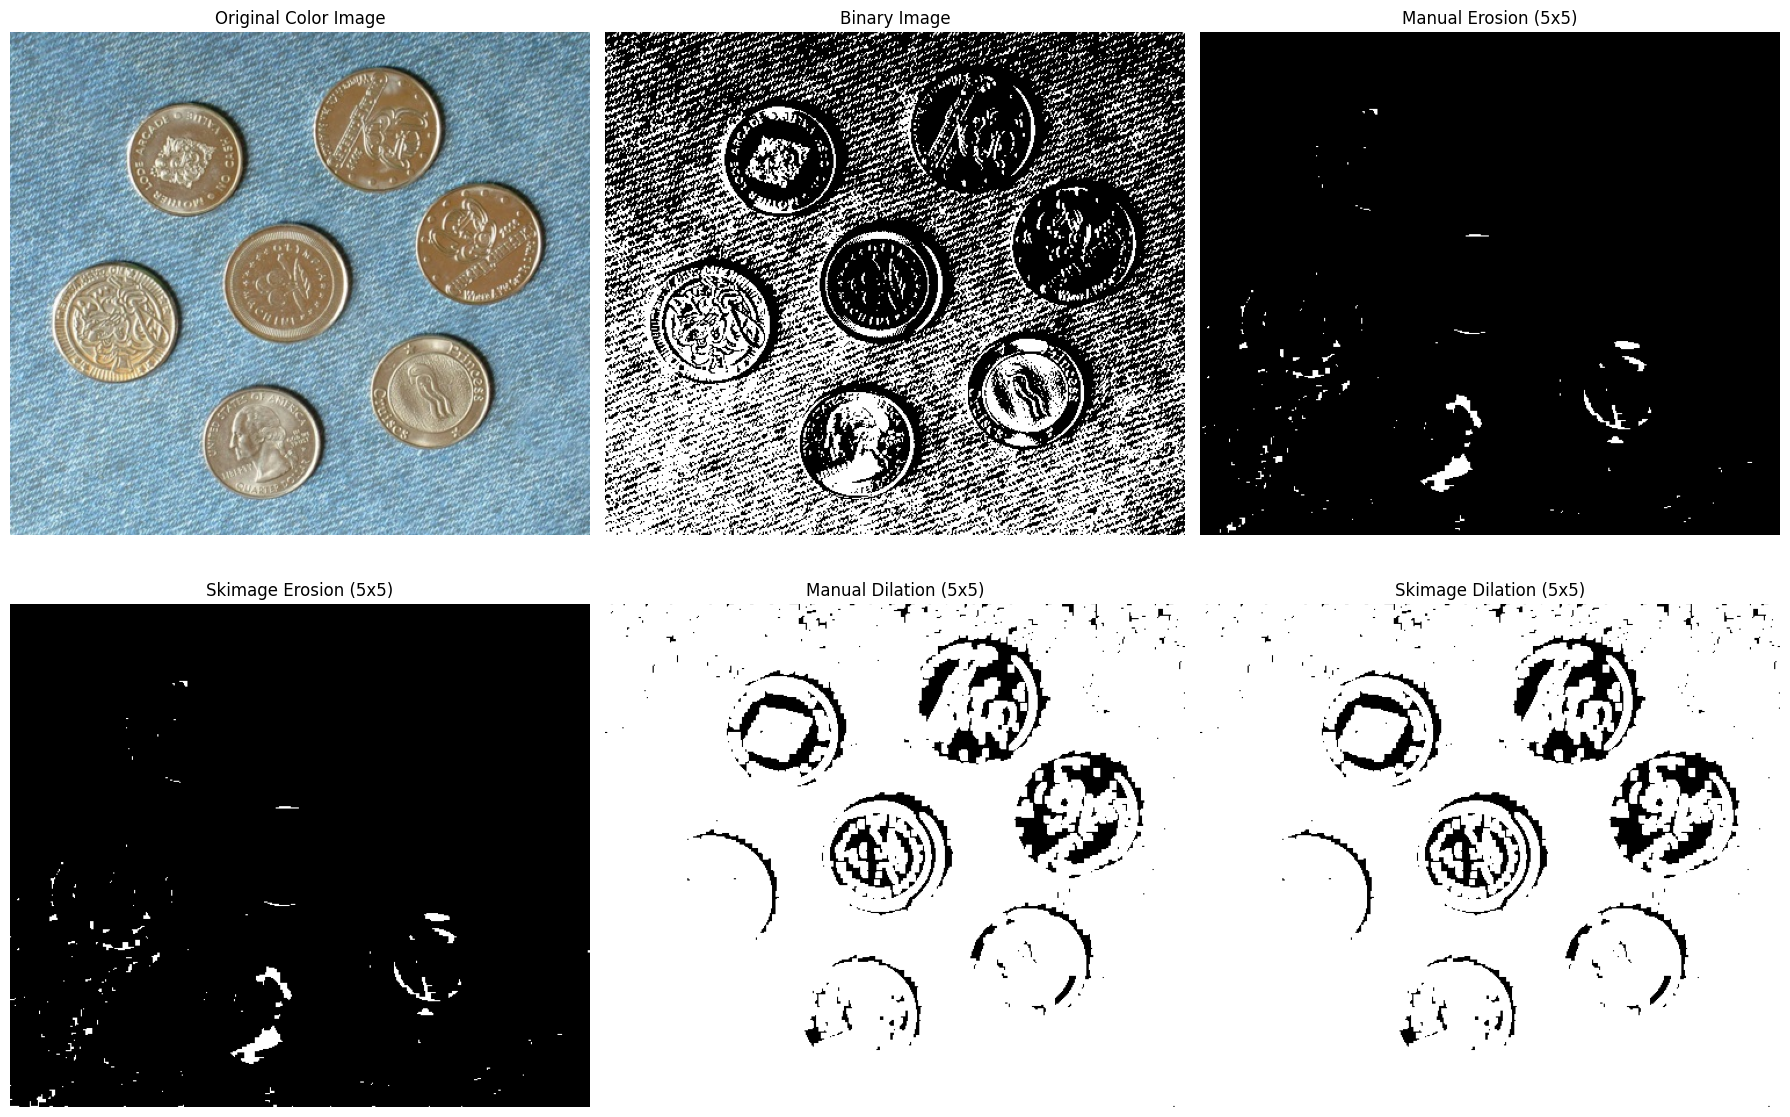

In [32]:
'''
1) Erosion / Dilation:
    - Load "coins.jpg" from the img folder
    - Convert the image to binary
    - Write 2 functions each applying 1 of the erosion/dilation algorithms (with adjustable square window size) manually to the binary image
    - Use Skimage's "binary_erosion" & "binary_dilation" & show the results
'''

image_path = 'img/coins.jpg'
image_color = io.imread(image_path)

image_gray = rgb2gray(image_color)

thresh = 0.6
binary_image = image_gray > thresh



def manual_erosion(image, window_size):
    pad_size = window_size // 2
    padded_image = np.pad(image, pad_width=pad_size, mode='constant', constant_values=0)
    eroded_image = np.zeros_like(image, dtype=bool)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            neighborhood = padded_image[i:i+window_size, j:j+window_size]
            if np.all(neighborhood):
                eroded_image[i, j] = True
    return eroded_image

def manual_dilation(image, window_size):
    pad_size = window_size // 2
    # Pad the image to handle borders
    padded_image = np.pad(image, pad_width=pad_size, mode='constant', constant_values=0)
    dilated_image = np.zeros_like(image, dtype=bool)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Extract the neighborhood
            neighborhood = padded_image[i:i+window_size, j:j+window_size]
            if np.any(neighborhood):
                dilated_image[i, j] = True
    return dilated_image

window_size = 5

# Apply the manual functions
manual_eroded = manual_erosion(binary_image, window_size)
manual_dilated = manual_dilation(binary_image, window_size)

# Apply Skimage's functions
structuring_element = np.ones((window_size, window_size))
skimage_eroded = binary_erosion(binary_image, structuring_element)
skimage_dilated = binary_dilation(binary_image, structuring_element)

# --- 4. Display the Results ---

# Create a figure to display all the images
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
ax = axes.ravel()

ax[0].imshow(image_color)
ax[0].set_title("Original Color Image")
ax[0].axis('off')

ax[1].imshow(binary_image, cmap='gray')
ax[1].set_title("Binary Image")
ax[1].axis('off')

ax[2].imshow(manual_eroded, cmap='gray')
ax[2].set_title(f"Manual Erosion ({window_size}x{window_size})")
ax[2].axis('off')

ax[3].imshow(skimage_eroded, cmap='gray')
ax[3].set_title(f"Skimage Erosion ({window_size}x{window_size})")
ax[3].axis('off')

ax[4].imshow(manual_dilated, cmap='gray')
ax[4].set_title(f"Manual Dilation ({window_size}x{window_size})")
ax[4].axis('off')

ax[5].imshow(skimage_dilated, cmap='gray')
ax[5].set_title(f"Skimage Dilation ({window_size}x{window_size})")
ax[5].axis('off')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

/tmp/ipykernel_5552/3117622997.py:21: FutureWarning: `rectangle` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  closed = binary_closing(binary, rect_selem(2, 15))
/tmp/ipykernel_5552/3117622997.py:22: FutureWarning: `rectangle` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  closed = binary_closing(closed, rect_selem(2, 2))


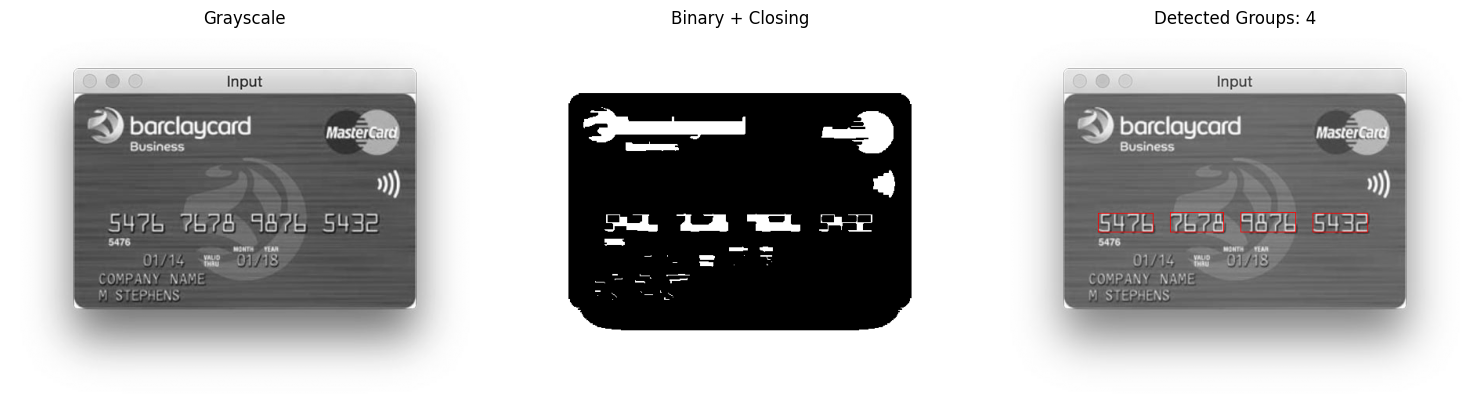

In [29]:
'''
2) Case Study: Credit Card Number Extraction
    - Load "card.jpg" from the img folder
    - Convert to binary by brightness thresholding maintaining the card number details for extraction
    - Use your erosion/dilation functions, or Skimage's functions only if you didn't implement them, to apply closing
        Note: The goal of this step is to join the card number into 4 sets of connected pixels
    - Use Skimage's "find_contours" to get the bounding boxes for the credit card's numbers by filtering on aspect ratio (between 2.5 & 3.5)
        Note: When using "find_contours(img, 0.8)" the o/p is a list of contours each having:
                - contour[:,0] being the Y values of the contour perimeter points
                - contour[:,1] being the X values of the contour perimeter points
'''

from skimage.morphology import rectangle as rect_selem
from skimage.draw import rectangle as draw_rectangle
from skimage.draw import rectangle_perimeter


img = rgb2gray(io.imread("img/card.jpg"))
binary = img > 0.7 

closed = binary_closing(binary, rect_selem(2, 15))
closed = binary_closing(closed, rect_selem(2, 2))

contours = find_contours(closed, 0.8)
boxes = []

h, w = img.shape
for c in contours:
    y1, y2 = np.min(c[:, 0]), np.max(c[:, 0])
    x1, x2 = np.min(c[:, 1]), np.max(c[:, 1])
    width, height = x2 - x1, y2 - y1
    if height == 0: 
        continue
    ar = width / height
    if 50 < width < 70 and 20 < height < 30:
        boxes.append((int(x1), int(y1), int(x2), int(y2)))


rgb = np.dstack([img]*3)
for (x1, y1, x2, y2) in boxes:
    rr, cc = rectangle_perimeter(start=(y1, x1), end=(y2, x2), shape=img.shape)
    rgb[rr, cc] = [1, 0, 0]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(img, cmap='gray'); ax[0].set_title("Grayscale"); ax[0].axis('off')
ax[1].imshow(closed, cmap='gray'); ax[1].set_title("Binary + Closing"); ax[1].axis('off')
ax[2].imshow(rgb); ax[2].set_title(f"Detected Groups: {len(boxes)}"); ax[2].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
'''
3) Skeletonization:
- Load "horse.jpg" from the img folder
- Use a binary threshold of 0.9 to remove invisible noise in the background
- Use Skimage's "skeletonize(image)" to acquire the image's skeleton & show it
- Use Skimage's "thin(image, max_iter)" with values of max_iter 5/10/15/20 & show it
'''

img_color = io.imread('img/horse.jpg')
img_gray = rgb2gray(img_color)

init_image = img_gray < 0.9

binary_image = ~init_image

skeleton = skeletonize(binary_image)

thin_5 = thin(binary_image, max_num_iter=5)
thin_10 = thin(binary_image, max_num_iter=10)
thin_15 = thin(binary_image, max_num_iter=15)
thin_20 = thin(binary_image, max_num_iter=20)

# --- 4. Display the Results ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
ax = axes.ravel()

ax[0].imshow(binary_image, cmap='gray')
ax[0].set_title("Binary Image (Threshold < 0.9)")
ax[0].axis('off')

ax[1].imshow(skeleton, cmap='gray')
ax[1].set_title("Skeletonization")
ax[1].axis('off')

ax[2].imshow(thin_5, cmap='gray')
ax[2].set_title("Thinning (max_iter = 5)")
ax[2].axis('off')

ax[3].imshow(thin_10, cmap='gray')
ax[3].set_title("Thinning (max_iter = 10)")
ax[3].axis('off')

ax[4].imshow(thin_15, cmap='gray')
ax[4].set_title("Thinning (max_iter = 15)")
ax[4].axis('off')

ax[5].imshow(thin_20, cmap='gray')
ax[5].set_title("Thinning (max_iter = 20)")
ax[5].axis('off')

plt.tight_layout()
plt.show()